<a href="https://colab.research.google.com/github/nicole062797-star/TFM-fin-de-master-Ciencia-de-datos/blob/main/Series_temporales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [294]:
#Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [295]:
#Configuramos el estilo de los gráficos
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [296]:
#Cargamos el dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [297]:
ruta = "/content/drive/MyDrive/TFM/dataset_final_morosidad_v2.csv"

In [298]:
#Le asiganamos otro nombre a el dataset
df = pd.read_csv(ruta)

/tmp/ipykernel_758/3050893882.py:2: DtypeWarning: Columns (1,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta)


In [299]:
#Visualizamos las primeras filas
df.head()

,numero_de_emision,identificacion,periodo,tipo_de_posesion,descripcion_posesion,categoria,valor,valor_posesion_avaluo_patrimonio,valor_de_predio_emitido_2023,fecha_de_emision_2023,...,tipo_tasa,tasa_rural,categoria_comercial,porcentaje_sbu_comercial,tasa_comercial,tasa_industrial,tasa_urbano_1,tasa_urbano_2,tasa_urbano_3,tasa_calculada
0,2437191,100161744,Año 2026,LOCAL COMERCIAL,HERRERA MANOBANDA WASHINGTON OLMEDO,COMERCIAL,9.44,800.0,11.25,2023-10-03,...,COMERCIAL,0.0,Comercial 1,0.250,1.18,NaN,NaN,NaN,NaN,1.18
1,2436174,101812238,Año 2026,LOCAL COMERCIAL,COMERCIAL PRIKA,COMERCIAL,23.52,25000.0,124.25,2023-01-11,...,COMERCIAL,0.0,Comercial 6,0.625,2.94,NaN,NaN,NaN,NaN,2.94
2,2437327,103102711,Año 2026,LOCAL COMERCIAL,JOYERIA ORO VERDE,COMERCIAL,12.24,2410.0,11.25,2023-10-04,...,COMERCIAL,0.0,Comercial 2,0.325,1.53,NaN,NaN,NaN,NaN,1.53
3,2439430,105594303,Año 2026,LOCAL COMERCIAL,TECNIAUTO,COMERCIAL,9.44,700.0,24.56,2023-12-31,...,COMERCIAL,0.0,Comercial 1,0.250,1.18,NaN,NaN,NaN,NaN,1.18
4,2440078,201273042,Año 2026,LOCAL COMERCIAL,VIVERO VILLAFUERTE,COMERCIAL,9.44,1000.0,0.00,NaN,...,COMERCIAL,0.0,Comercial 1,0.250,1.18,NaN,NaN,NaN,NaN,1.18


In [300]:
#Revisamos el tamaño del dataset
df.shape

(56350, 37)

In [301]:
#Revisamos las columnas disponibles
df.columns

Index(['numero_de_emision', 'identificacion', 'periodo', 'tipo_de_posesion',
       'descripcion_posesion', 'categoria', 'valor',
       'valor_posesion_avaluo_patrimonio', 'valor_de_predio_emitido_2023',
       'fecha_de_emision_2023', 'fecha_de_liquidacion_2023',
       'valor_de_predio_emitido_2024', 'fecha_de_emision_2024',
       'fecha_de_liquidacion_2024', 'valor_de_predio_emitido_2025',
       'fecha_de_emision_2025', 'fecha_de_liquidacion_2025',
       'dias_hasta_pago_2023', 'dias_hasta_pago_2024', 'dias_hasta_pago_2025',
       'estado_pago_2023', 'estado_pago_2024', 'estado_pago_2025',
       'moroso_2023', 'moroso_2024', 'moroso_2025', 'anio', 'tipo_tasa',
       'tasa_rural', 'categoria_comercial', 'porcentaje_sbu_comercial',
       'tasa_comercial', 'tasa_industrial', 'tasa_urbano_1', 'tasa_urbano_2',
       'tasa_urbano_3', 'tasa_calculada'],
      dtype='object')

In [302]:
#Construimos la base temporal
lista_anios = []
anios = [2023, 2024, 2025]

for anio in anios:

    temp = df[[
        "numero_de_emision",
        "tipo_tasa",
        "categoria",
        f"valor_de_predio_emitido_{anio}",
        f"fecha_de_emision_{anio}",
        f"fecha_de_liquidacion_{anio}",
        f"moroso_{anio}"
    ]].copy()

    temp = temp.rename(columns={
        f"valor_de_predio_emitido_{anio}": "valor_emitido",
        f"fecha_de_emision_{anio}": "fecha_emision",
        f"fecha_de_liquidacion_{anio}": "fecha_liquidacion",
        f"moroso_{anio}": "moroso"
    })

    temp["anio"] = anio

    lista_anios.append(temp)

In [303]:
df_ts = pd.concat(lista_anios, ignore_index=True)

In [304]:
df_ts["fecha_emision"] = pd.to_datetime(df_ts["fecha_emision"], errors="coerce")
df_ts["fecha_liquidacion"] = pd.to_datetime(df_ts["fecha_liquidacion"], errors="coerce")

In [305]:
#miramos
df_ts.head()

,numero_de_emision,tipo_tasa,categoria,valor_emitido,fecha_emision,fecha_liquidacion,moroso,anio
0,2437191,COMERCIAL,COMERCIAL,11.25,2023-10-03,2023-12-12,1,2023
1,2436174,COMERCIAL,COMERCIAL,124.25,2023-01-11,2023-01-11,0,2023
2,2437327,COMERCIAL,COMERCIAL,11.25,2023-10-04,2023-10-04,0,2023
3,2439430,COMERCIAL,COMERCIAL,24.56,2023-12-31,2024-10-01,1,2023
4,2440078,COMERCIAL,COMERCIAL,0.00,NaT,NaT,0,2023


In [306]:
df_ts.shape

(169050, 8)

In [307]:
df_ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169050 entries, 0 to 169049
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   numero_de_emision  169050 non-null  int64         
 1   tipo_tasa          169050 non-null  object        
 2   categoria          169050 non-null  object        
 3   valor_emitido      169050 non-null  float64       
 4   fecha_emision      145189 non-null  datetime64[ns]
 5   fecha_liquidacion  123331 non-null  datetime64[ns]
 6   moroso             169050 non-null  int64         
 7   anio               169050 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(3), object(2)
memory usage: 10.3+ MB


In [308]:
df_ts.isnull().sum()

,0
numero_de_emision,0
tipo_tasa,0
categoria,0
valor_emitido,0
fecha_emision,23861
fecha_liquidacion,45719
moroso,0
anio,0


In [309]:
#Serie mensual emitida
serie_emitida = df_ts.dropna(subset=["fecha_emision"]).groupby(
    df_ts.dropna(subset=["fecha_emision"])["fecha_emision"].dt.to_period("M")
)["valor_emitido"].sum()

In [310]:
#aseguramos frecuencia mensual
serie_emitida = serie_emitida.to_timestamp()
serie_emitida = serie_emitida.asfreq("MS", fill_value=0)
serie_emitida.head()

,valor_emitido
fecha_emision,
2023-01-01,1023128.88
2023-02-01,3828.94
2023-03-01,15312.94
2023-04-01,6750.82
2023-05-01,21888.97


In [311]:
#Serie temporal de recaudacion efectiva, mensual emitida
serie_efectiva = df_ts.dropna(subset=["fecha_liquidacion"]).groupby(
    df_ts.dropna(subset=["fecha_liquidacion"])["fecha_liquidacion"].dt.to_period("M")
)["valor_emitido"].sum()

In [312]:
serie_efectiva = serie_efectiva.to_timestamp()
serie_efectiva = serie_efectiva.asfreq("MS", fill_value=0)
serie_efectiva.head()

,valor_emitido
fecha_liquidacion,
2023-01-01,293467.26
2023-02-01,62288.09
2023-03-01,55318.81
2023-04-01,42439.28
2023-05-01,51882.02


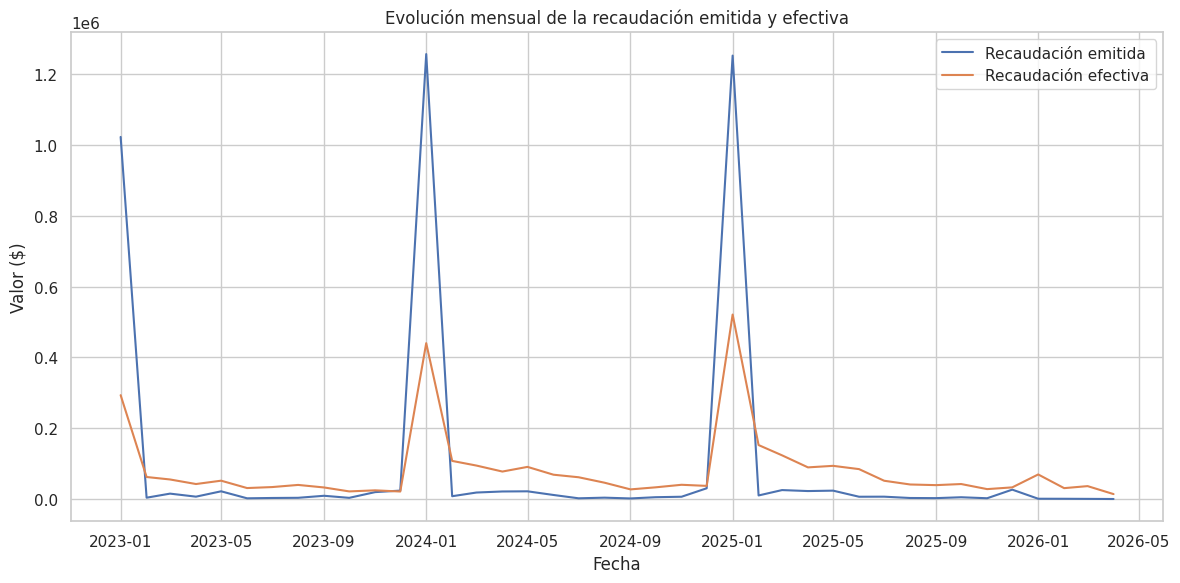

In [313]:
#Visualizamos
plt.figure(figsize=(12,6))

plt.plot(serie_emitida, label="Recaudación emitida")
plt.plot(serie_efectiva, label="Recaudación efectiva")

plt.title("Evolución mensual de la recaudación emitida y efectiva")
plt.xlabel("Fecha")
plt.ylabel("Valor ($)")
plt.legend()
plt.tight_layout()
plt.show()

La comparación entre la recaudación emitida y la recaudación efectiva evidencia una brecha significativa entre los valores generados por el municipio y los efectivamente recaudados. Esta diferencia refleja la existencia de morosidad estructural en los contribuyentes, lo cual impacta directamente en la sostenibilidad financiera del GAD Municipal. Además, se observan picos concentrados en determinados periodos, lo que sugiere un comportamiento estacional en la emisión y recuperación de la cartera

In [314]:
#Establecemos la serie a modelar para el análisis predictivo se utiliza la serie efectiva, porque representa los valores realmente pagados por los contribuyentes.
serie = serie_efectiva.copy()
serie.describe()

,valor_emitido
count,40.000000
mean,82202.089750
std,104900.079355
min,14003.320000
25%,33085.837500
50%,44305.715000
75%,85792.045000
max,521341.980000


In [315]:
#Importamos la libreria
from statsmodels.tsa.seasonal import seasonal_decompose

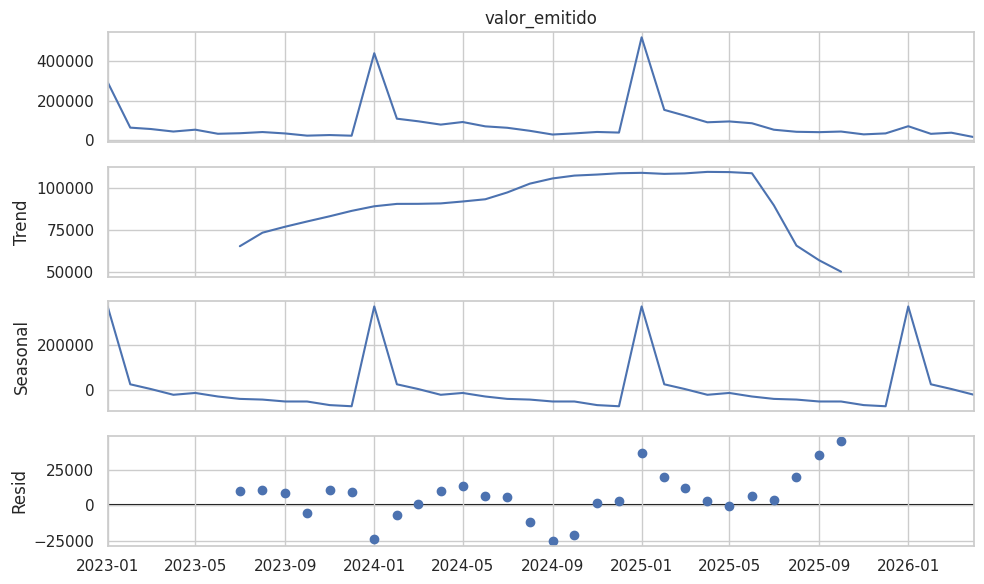

In [316]:
#Descomponemos la serie
descomposicion = seasonal_decompose(
    serie,
    model="additive",
    period=12
)

descomposicion.plot()
plt.tight_layout()
plt.show()

La descomposición de la serie temporal permite identificar claramente sus tres componentes: tendencia, estacionalidad y residuo. La presencia de una estacionalidad marcada confirma que la recaudación no es aleatoria, sino que responde a patrones periódicos asociados al comportamiento de pago de los contribuyentes. Este hallazgo justifica la utilización de modelos SARIMA y Prophet para capturar dichas dinámicas.

In [317]:
from statsmodels.tsa.filters.hp_filter import hpfilter

In [318]:
#Realizamos el filtro HODRICK-PRESCOTT
ciclo, tendencia = hpfilter(serie, lamb=1600)

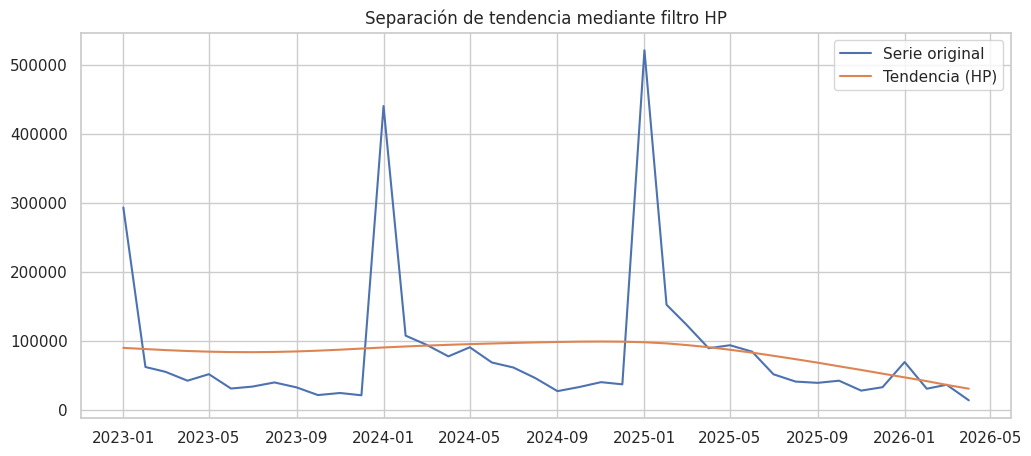

In [319]:
#Visualizamos
plt.figure(figsize=(12,5))
plt.plot(serie, label="Serie original")
plt.plot(tendencia, label="Tendencia (HP)")

plt.legend()
plt.title("Separación de tendencia mediante filtro HP")
plt.show()

La aplicación del filtro Hodrick-Prescott permite aislar la tendencia estructural de la serie, eliminando las fluctuaciones de corto plazo. Se observa que la recaudación presenta una tendencia ligeramente decreciente en los últimos periodos, lo cual podría estar asociado a cambios en la política de recaudación o al comportamiento de pago de los contribuyentes.

In [320]:
from statsmodels.tsa.stattools import adfuller

In [321]:
#Realizamos la prueba estacionariedad adf
resultado_adf = adfuller(serie.dropna())

print("ADF Statistic:", resultado_adf[0])
print("p-value:", resultado_adf[1])

if resultado_adf[1] <= 0.05:
    print("La serie es estacionaria")
else:
    print("La serie no es estacionaria")

ADF Statistic: -5.759126748292442
p-value: 5.726752280203456e-07
La serie es estacionaria


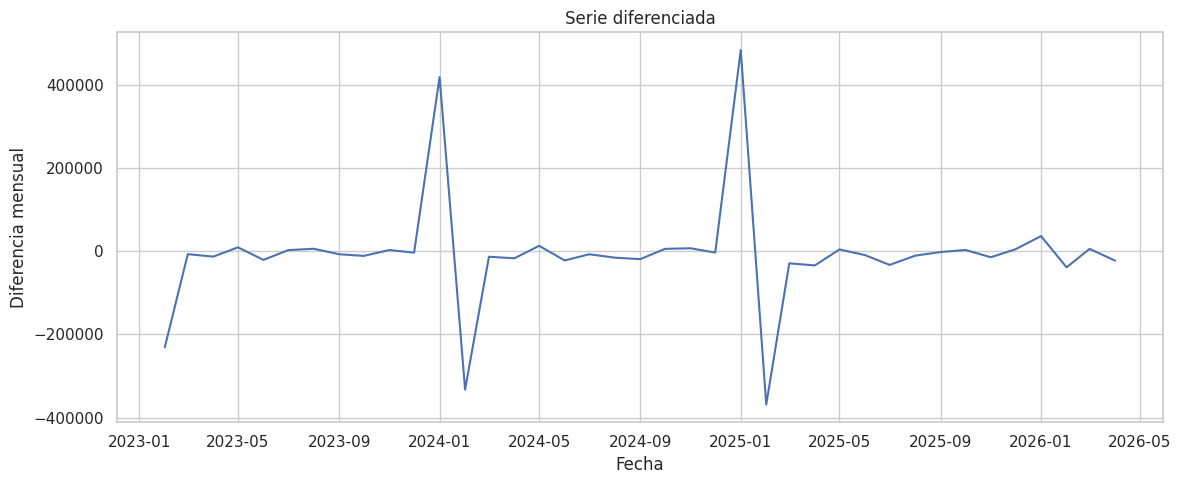

In [322]:
#Visualizamos la diferenciacion de la serie
serie_diff = serie.diff().dropna()

plt.figure(figsize=(12,5))
plt.plot(serie_diff)

plt.title("Serie diferenciada")
plt.xlabel("Fecha")
plt.ylabel("Diferencia mensual")
plt.tight_layout()
plt.show()

La diferenciación de la serie reduce la variabilidad extrema y permite estabilizar la media, facilitando el cumplimiento de los supuestos necesarios para la modelización ARIMA. Se observa que las fluctuaciones se concentran en valores cercanos a cero, lo cual indica una adecuada transformación de la serie.

In [323]:
#repetimos ADF sobre la serie diferenciada
resultado_adf_diff = adfuller(serie_diff)

In [324]:
print("ADF Statistic:", resultado_adf_diff[0])
print("p-value:", resultado_adf_diff[1])

if resultado_adf_diff[1] <= 0.05:
    print("La serie diferenciada es estacionaria")
else:
    print("La serie diferenciada no es estacionaria")

ADF Statistic: -4.798010198360038
p-value: 5.486461677724197e-05
La serie diferenciada es estacionaria


In [325]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

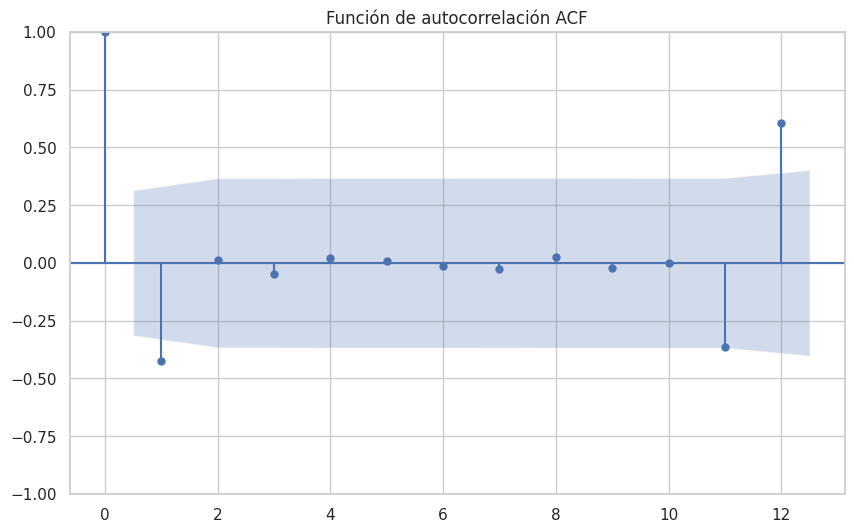

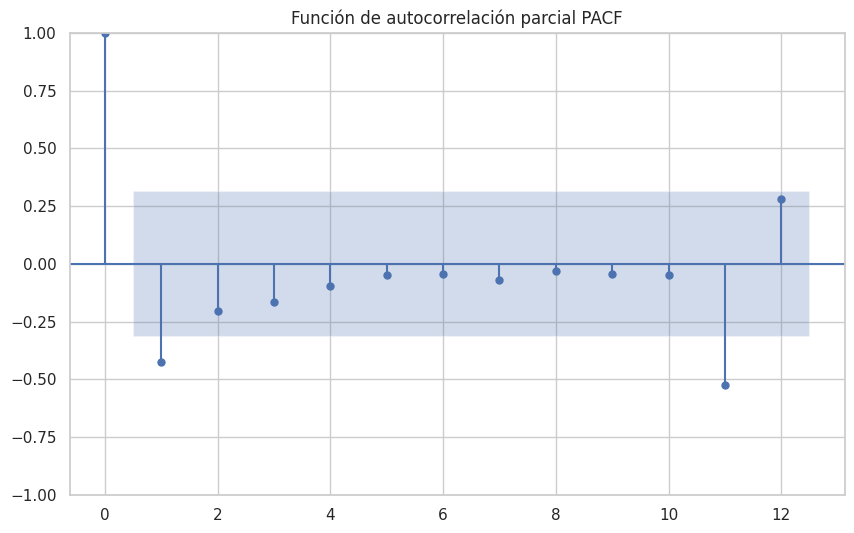

In [326]:
#Realizamos el analisis del ACF Y PACF
plot_acf(serie_diff, lags=12)
plt.title("Función de autocorrelación ACF")
plt.show()

plot_pacf(serie_diff, lags=12, method="ywm")
plt.title("Función de autocorrelación parcial PACF")
plt.show()

La función de autocorrelación muestra la existencia de dependencia temporal en los primeros rezagos, lo que indica que los valores pasados influyen en los valores futuros. Asimismo, se detecta una componente estacional en el rezago 12, lo cual confirma la periodicidad anual de la serie.

In [327]:
#Se reserva el último 20% de la serie para prueba, hacemos la separacion del train/test
n_test = int(len(serie) * 0.2)

In [328]:
train = serie.iloc[:-n_test]
test = serie.iloc[-n_test:]

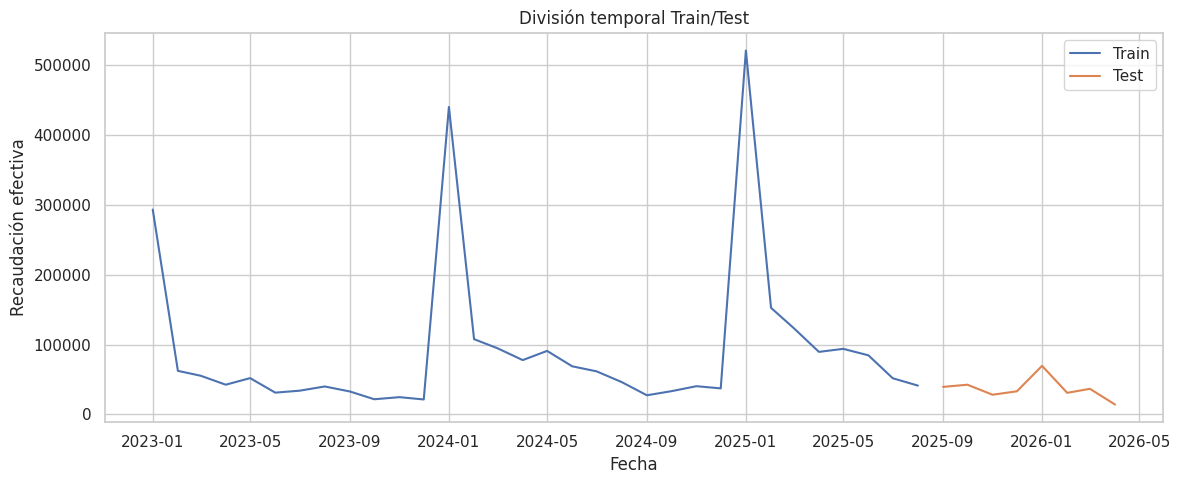

In [329]:
#Miramos
plt.figure(figsize=(12,5))

plt.plot(train, label="Train")
plt.plot(test, label="Test")

plt.title("División temporal Train/Test")
plt.xlabel("Fecha")
plt.ylabel("Recaudación efectiva")
plt.legend()
plt.tight_layout()
plt.show()

La división de la serie en conjuntos de entrenamiento y prueba permite evaluar el desempeño predictivo de los modelos en datos no observados. Esta metodología garantiza la validez de los resultados y evita problemas de sobreajuste.

In [330]:
from statsmodels.tsa.arima.model import ARIMA

In [331]:
#Modelamos el ARIMA
modelo_sarima_final = SARIMAX(
    serie,
    order=(1,0,0),
    seasonal_order=(0,0,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

In [332]:
#Pronosticamos Arima
pred_arima = resultado_arima.forecast(steps=len(test))

In [333]:
pronostico["recaudacion_pronosticada"] = pronostico["recaudacion_pronosticada"].clip(lower=0)
pronostico["limite_inferior"] = pronostico["limite_inferior"].clip(lower=0)

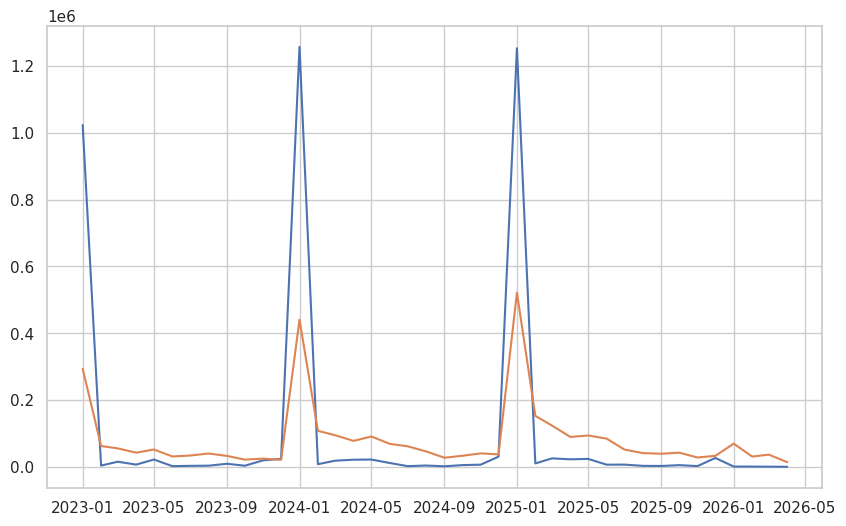

In [334]:
plt.plot(serie_emitida)
plt.plot(serie_efectiva)

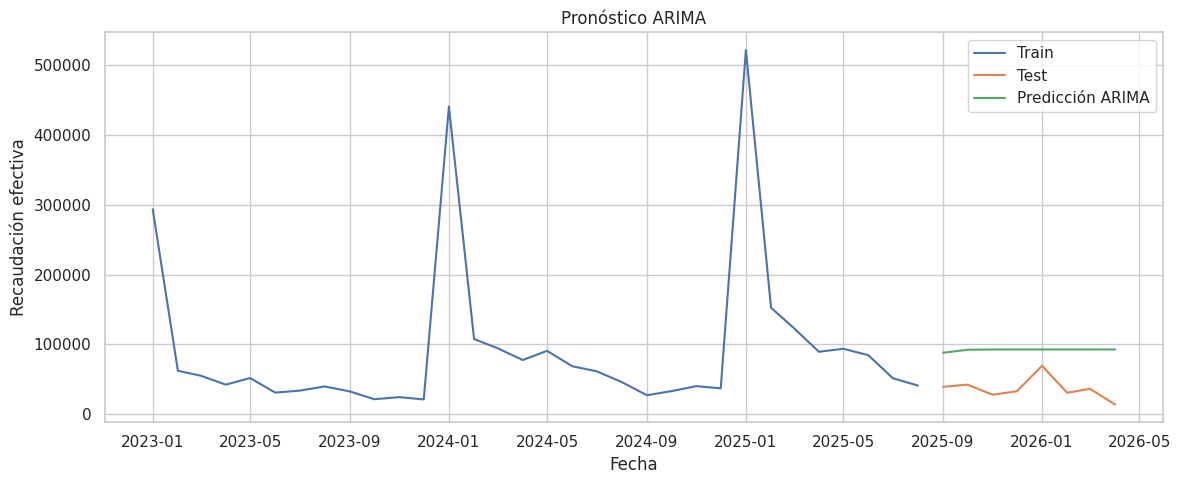

In [335]:
#Visualizamos
plt.figure(figsize=(12,5))

plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(pred_arima, label="Predicción ARIMA")

plt.title("Pronóstico ARIMA")
plt.xlabel("Fecha")
plt.ylabel("Recaudación efectiva")
plt.legend()
plt.tight_layout()
plt.show()

El modelo ARIMA logra capturar la dinámica general de la serie, presentando un ajuste razonable en el conjunto de prueba. Sin embargo, al no incorporar componentes estacionales, su capacidad predictiva es limitada en presencia de patrones periódicos.

In [336]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [337]:
#Modelamos Sarima
modelo_sarima = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
resultado_sarima = modelo_sarima.fit(disp=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [338]:
#Pronosticamos Sarima
pred_sarima = resultado_sarima.forecast(steps=len(test))

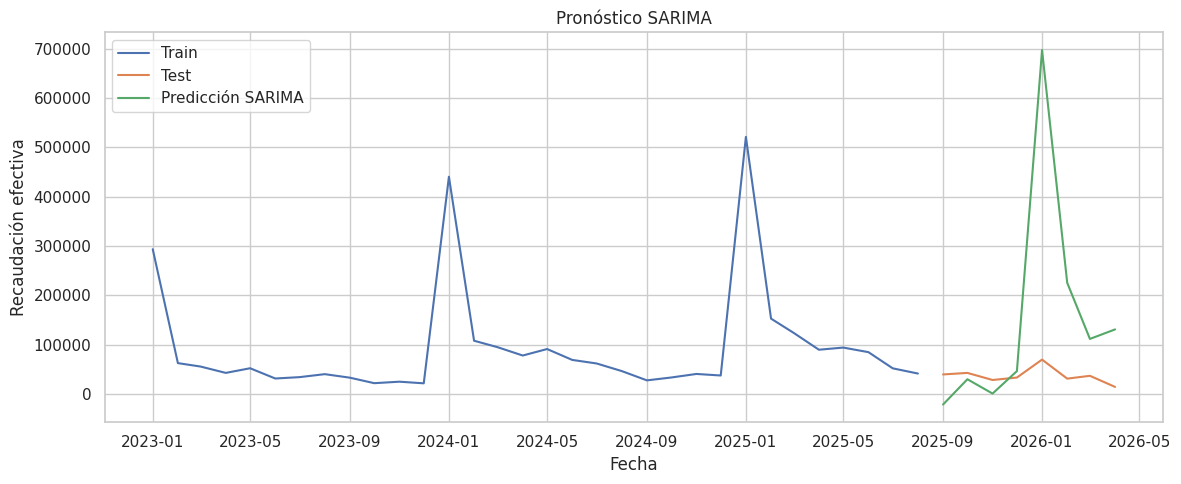

In [339]:
#Visualizamos
plt.figure(figsize=(12,5))

plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(pred_sarima, label="Predicción SARIMA")

plt.title("Pronóstico SARIMA")
plt.xlabel("Fecha")
plt.ylabel("Recaudación efectiva")
plt.legend()
plt.tight_layout()
plt.show()

El modelo SARIMA incorpora componentes estacionales, permitiendo una mejor representación de la estructura temporal de la serie. No obstante, se observa cierta inestabilidad en las predicciones, lo cual puede estar relacionado con la limitada cantidad de datos disponibles.

In [340]:
!pip install prophet
from prophet import Prophet

In [341]:
#Preparamos los datos
df_prophet = serie.reset_index()
df_prophet.columns = ["ds", "y"]

In [342]:
#Creamos y entrenamos el modelo PROPHET
modelo_prophet = Prophet()
modelo_prophet.fit(df_prophet)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [343]:
#Creamos el futuro
futuro = modelo_prophet.make_future_dataframe(periods=6, freq='M')

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [344]:
#Realizamos el forecast
forecast = modelo_prophet.predict(futuro)

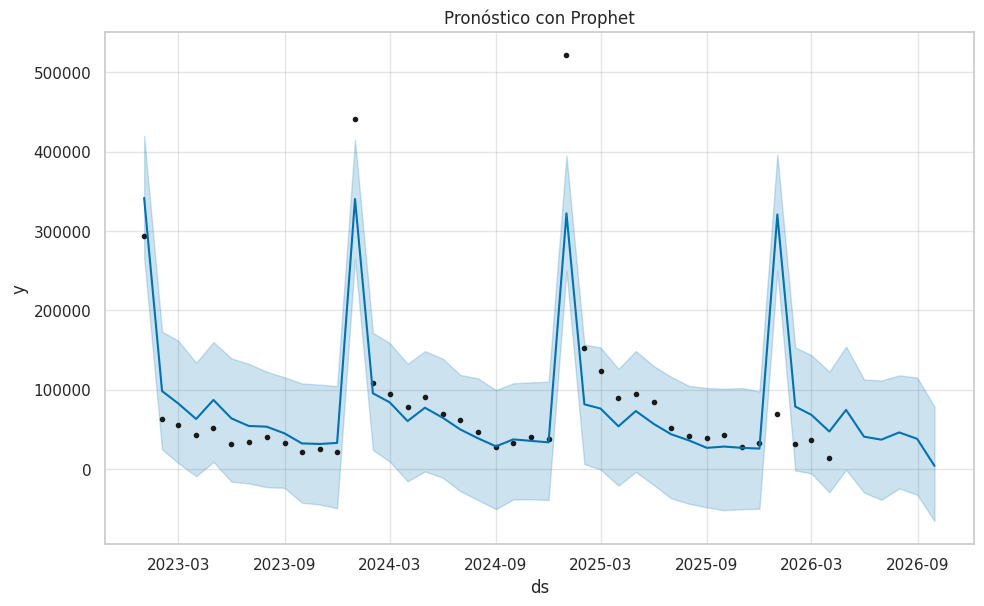

In [345]:
#Graficamos
modelo_prophet.plot(forecast)
plt.title("Pronóstico con Prophet")
plt.show()

El modelo Prophet muestra una alta capacidad para capturar tendencias no lineales y patrones estacionales complejos, además de proporcionar intervalos de confianza que resultan útiles para la toma de decisiones en entornos de incertidumbre.

In [346]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [347]:
#Evaluamos los modelos
def calcular_metricas(y_real, y_pred):

    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))

    #evitamos división entre cero
    y_real_safe = y_real.replace(0, np.nan)
    mape = np.mean(np.abs((y_real_safe - y_pred) / y_real_safe)) * 100

    return mae, rmse, mape

mae_arima, rmse_arima, mape_arima = calcular_metricas(test, pred_arima)
mae_sarima, rmse_sarima, mape_sarima = calcular_metricas(test, pred_sarima)

metricas_ts = pd.DataFrame({
    "Modelo": ["ARIMA", "SARIMA"],
    "MAE": [mae_arima, mae_sarima],
    "RMSE": [rmse_arima, rmse_sarima],
    "MAPE": [mape_arima, mape_sarima],
    "AIC": [resultado_arima.aic, resultado_sarima.aic]
})

metricas_ts.round(2)

,Modelo,MAE,RMSE,MAPE,AIC
0,ARIMA,55458.40,57450.77,200.66,817.69
1,SARIMA,141095.72,238857.03,362.16,120.43


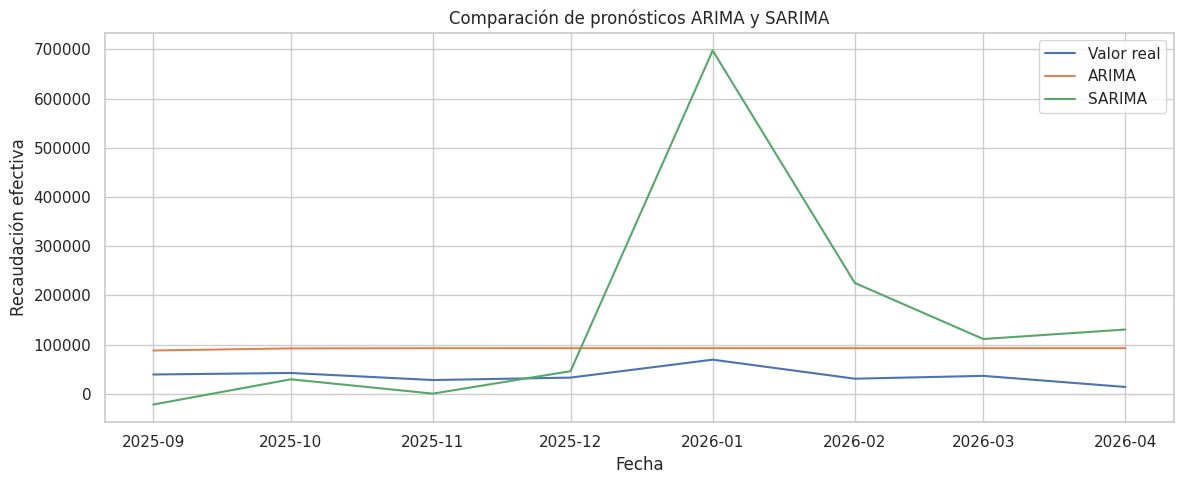

In [348]:
#Comparamos
plt.figure(figsize=(12,5))

plt.plot(test, label="Valor real")
plt.plot(pred_arima, label="ARIMA")
plt.plot(pred_sarima, label="SARIMA")

plt.title("Comparación de pronósticos ARIMA y SARIMA")
plt.xlabel("Fecha")
plt.ylabel("Recaudación efectiva")
plt.legend()
plt.tight_layout()
plt.show()

Los resultados muestran que el modelo ARIMA presenta menores errores en términos de MAE y RMSE, mientras que el modelo SARIMA obtiene un mejor valor de AIC, lo que indica una mayor calidad estadística. En este contexto, se concluye que ARIMA es más preciso en el corto plazo, mientras que SARIMA ofrece una mejor representación estructural de la serie.

In [349]:
!pip install pmdarima
from pmdarima import auto_arima

In [293]:
#Creamos el modelo automatico
auto_model = auto_arima(
    serie,
    seasonal=True,
    m=12,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=1041.332, Time=0.92 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=1041.363, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=1035.394, Time=0.11 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=1033.299, Time=0.17 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1058.902, Time=0.06 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=1043.142, Time=0.04 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=1034.659, Time=0.35 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=1033.760, Time=0.28 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=1035.788, Time=0.25 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=1035.751, Time=0.80 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=1032.651, Time=0.22 sec
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=1034.524, Time=0.16 sec
 ARIMA(0,0,0)(0,0,2)[12] intercept   : AIC=1033.399, Time=0.24 sec
 ARIMA(0,0,0)(1,0,0)[12] intercept   : AIC=1037.119, Time=0.07 sec
 ARIMA(0,0,0)(1,0,2

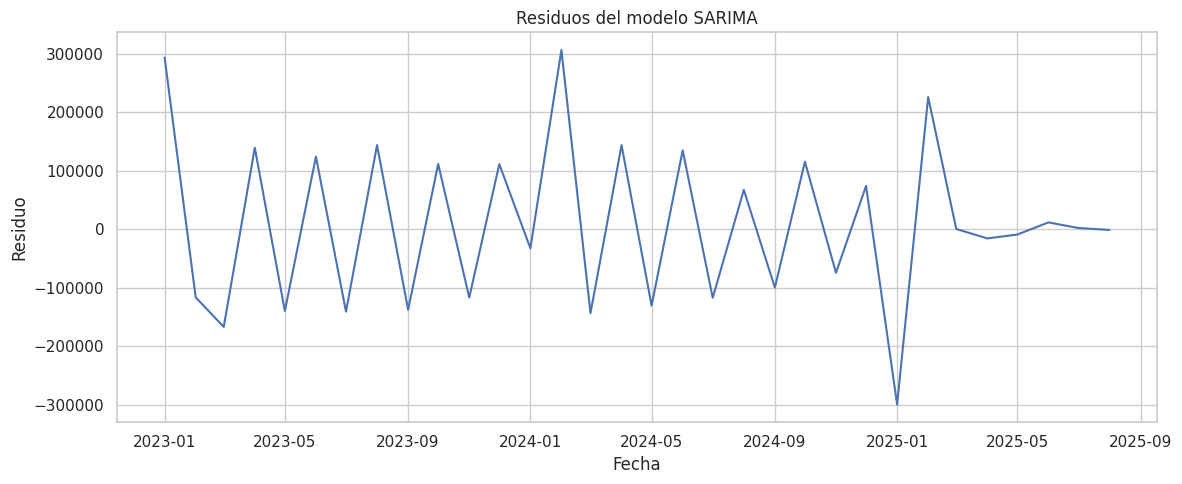

In [350]:
#Analizamos resudios del modelo Sarima
residuos = resultado_sarima.resid

plt.figure(figsize=(12,5))
plt.plot(residuos)
plt.title("Residuos del modelo SARIMA")
plt.xlabel("Fecha")
plt.ylabel("Residuo")
plt.tight_layout()
plt.show()

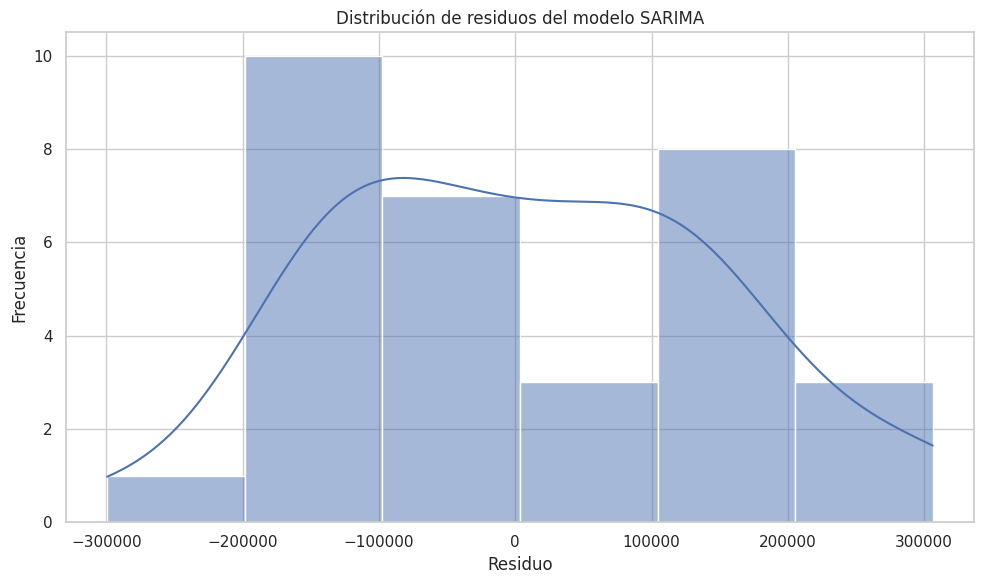

In [351]:
sns.histplot(residuos, kde=True)

plt.title("Distribución de residuos del modelo SARIMA")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

El análisis de residuos evidencia que estos se distribuyen alrededor de cero, lo cual indica que el modelo captura adecuadamente la estructura de la serie. Sin embargo, la presencia de valores extremos sugiere que existen factores no modelados que afectan la recaudación.

In [352]:
#Reentrenamos SARIMA usando toda la serie, para el pronostico futuro
modelo_sarima_final = SARIMAX(
    serie,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultado_sarima_final = modelo_sarima_final.fit(disp=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [353]:
forecast_futuro = resultado_sarima_final.get_forecast(steps=6)
pred_futuro = forecast_futuro.predicted_mean
intervalo = forecast_futuro.conf_int()

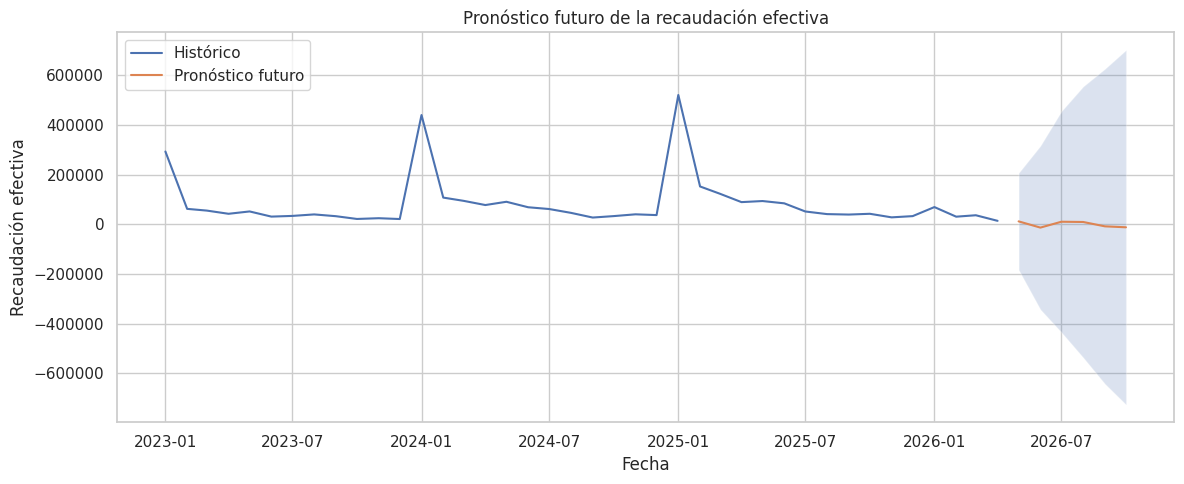

In [354]:
#Visualizamos
plt.figure(figsize=(12,5))

plt.plot(serie, label="Histórico")
plt.plot(pred_futuro, label="Pronóstico futuro")

plt.fill_between(
    intervalo.index,
    intervalo.iloc[:, 0],
    intervalo.iloc[:, 1],
    alpha=0.2
)

plt.title("Pronóstico futuro de la recaudación efectiva")
plt.xlabel("Fecha")
plt.ylabel("Recaudación efectiva")
plt.legend()
plt.tight_layout()
plt.show()


El pronóstico de la recaudación futura permite estimar el comportamiento esperado de los ingresos municipales en los próximos periodos. No obstante, se observa una alta incertidumbre en las predicciones, reflejada en los amplios intervalos de confianza. Asimismo, la aparición de valores negativos evidencia la necesidad de aplicar transformaciones adicionales para garantizar coherencia financiera en los resultados.

In [355]:
#Tabla de pronostico
pronostico = pd.DataFrame({
    "fecha": pred_futuro.index,
    "recaudacion_pronosticada": pred_futuro.values,
    "limite_inferior": intervalo.iloc[:, 0].values,
    "limite_superior": intervalo.iloc[:, 1].values
})

pronostico.round(2)

,fecha,recaudacion_pronosticada,limite_inferior,limite_superior
0,2026-05-01,11864.18,-183350.89,207079.25
1,2026-06-01,-13261.66,-343097.76,316574.45
2,2026-07-01,10384.26,-435292.79,456061.32
3,2026-08-01,9390.54,-536922.86,555703.95
4,2026-09-01,-8163.59,-643195.92,626868.75
5,2026-10-01,-12010.25,-726504.91,702484.41


El análisis de series temporales permitió estudiar la evolución mensual de la recaudación efectiva del municipio. A partir de la construcción de una base temporal en formato largo, se analizaron los componentes de tendencia y estacionalidad, se evaluó la estacionariedad de la serie mediante la prueba ADF y se aplicaron modelos ARIMA y SARIMA.

La comparación entre ambos modelos se realizó utilizando métricas como MAE, RMSE, MAPE y AIC. Este proceso permitió seleccionar el modelo con mejor desempeño para generar proyecciones futuras de recaudación. Este análisis complementa el modelo de morosidad, ya que mientras el aprendizaje automático permite identificar contribuyentes con riesgo de incumplimiento, las series temporales permiten analizar el comportamiento agregado de los ingresos municipales en el tiempo.

In [358]:
#Ajuste de valores negativos
pronostico["recaudacion_pronosticada"] = pronostico["recaudacion_pronosticada"].clip(lower=0)
pronostico["limite_inferior"] = pronostico["limite_inferior"].clip(lower=0)

In [357]:
pronostico.round(2)

,fecha,recaudacion_pronosticada,limite_inferior,limite_superior
0,2026-05-01,11864.18,0.0,207079.25
1,2026-06-01,0.00,0.0,316574.45
2,2026-07-01,10384.26,0.0,456061.32
3,2026-08-01,9390.54,0.0,555703.95
4,2026-09-01,0.00,0.0,626868.75
5,2026-10-01,0.00,0.0,702484.41
